In [1]:
# https://jiha-kim.github.io/posts/introduction-to-stochastic-calculus/#b3-python-code-for-basic-sde-simulation
import apple

In [2]:
X=apple.jit('''
λμ.λσ.
{ dW ← [cos.(2*𝜋*x)*√(_2*_.y)]`(𝔯 0 1::Vec 1000 float) (𝔯 0 1)
; dt ← 0.001
; [x+μ*dt+σ*√dt*y] Λₒ 0 dW
}
''')

In [3]:
import numpy as np;import matplotlib.pyplot as plt

In [4]:
mu,sigma = 1.0, 0.5
t=np.linspace(0,1,1001)

In [5]:
# Simulate simple SDE: dX = mu dt + sigma dW
np.random.seed(42)
N=1000
dt = 1/N
X_py = np.zeros(N+1)
for i in range(N):
    dW = np.sqrt(dt) * np.random.normal(0, 1)
    X_py[i+1] = X_py[i] + mu * dt + sigma * dW

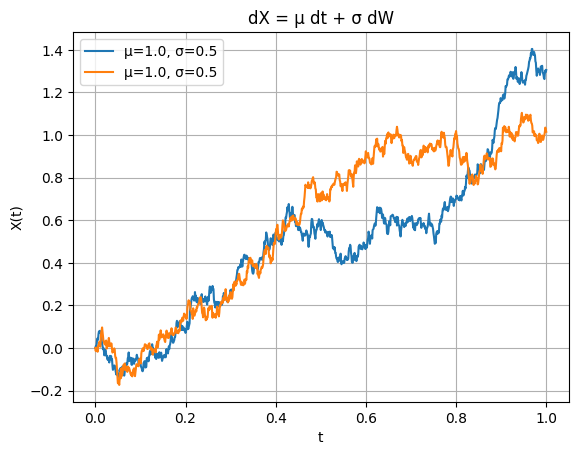

In [6]:
plt.plot(t,X_py,label=f"μ={mu}, σ={sigma}")
plt.plot(t,X(mu,sigma),label=f"μ={mu}, σ={sigma}")
plt.title("dX = μ dt + σ dW")
plt.xlabel("t");plt.ylabel("X(t)")
plt.legend();plt.grid(True)
plt.show()